In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("dataset/train.csv")

In [3]:
df = df.drop(columns=['id'])

In [4]:
df.isnull().sum()

age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0
dtype: int64

## Exploratory Data Analysis
### How many observations are in the dataset, and is each id truly unique?

In [5]:
print(f"The number of observations in the dataset is {df.shape[0]} and the number of features is {df.shape[1]}.")
#print(f"The number of unique students in the dataset is {df['id'].nunique()}.")

The number of observations in the dataset is 630000 and the number of features is 12.


### What are the data types of each feature, and which ones are categorical vs numerical?

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   age               630000 non-null  int64  
 1   gender            630000 non-null  object 
 2   course            630000 non-null  object 
 3   study_hours       630000 non-null  float64
 4   class_attendance  630000 non-null  float64
 5   internet_access   630000 non-null  object 
 6   sleep_hours       630000 non-null  float64
 7   sleep_quality     630000 non-null  object 
 8   study_method      630000 non-null  object 
 9   facility_rating   630000 non-null  object 
 10  exam_difficulty   630000 non-null  object 
 11  exam_score        630000 non-null  float64
dtypes: float64(4), int64(1), object(7)
memory usage: 57.7+ MB


**Numerical features**  
> age, study_hours, class_attendance, sleep_hours, exam_score  

**Categorical features**  
> gender, course, internet_access, sleep_quality, study_method, facility_rating, exam_difficulty

### Are there any extreme outliers in numerical features?

In [7]:
# Summary statistics for numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,630000.0,20.545821,2.260238,17.000,19.00,21.0,23.00,24.00
study_hours,630000.0,4.002337,2.359880,0.080,1.97,4.0,6.05,7.91
class_attendance,630000.0,71.987261,17.430098,40.600,57.00,72.6,87.20,99.40
sleep_hours,630000.0,7.072758,1.744811,4.100,5.60,7.1,8.60,9.90
exam_score,630000.0,62.506672,18.916884,19.599,48.80,62.6,76.30,100.00


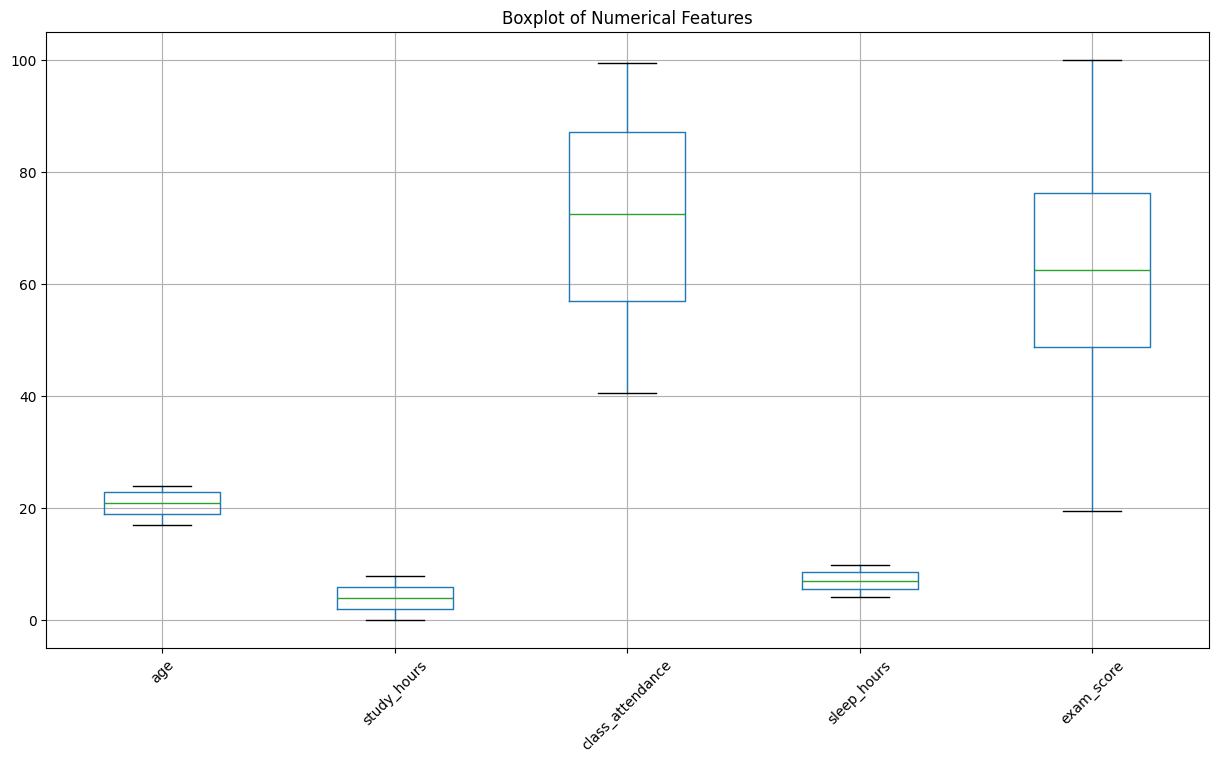

In [8]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(15, 8))
df[numeric_cols].boxplot()
plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.show()

> There are no outliers in the numerical features!

### Are there duplicated rows or suspicious repeated patterns across records?

In [9]:
df.duplicated().sum()

0

### What is the distribution of exam_score (normal, skewed, bimodal)? Are there ceiling or floor effects in exam_score (many 0s or 100s)?

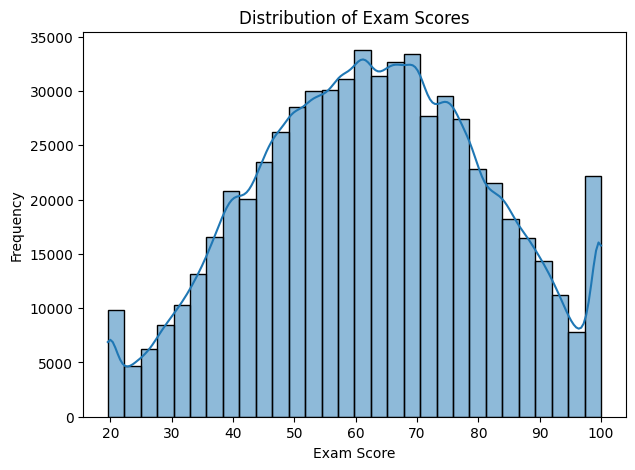

In [10]:
plt.figure(figsize=(7, 5))
sns.histplot(df['exam_score'], bins=30, kde=True)
plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()

In [11]:
df['exam_score'].describe()

count    630000.000000
mean         62.506672
std          18.916884
min          19.599000
25%          48.800000
50%          62.600000
75%          76.300000
max         100.000000
Name: exam_score, dtype: float64

df['exam_score'].skew()

> A normal distribution must have equal tails on both sides.
> This distribution is NOT normal! It has a central bell‑shaped region, but the tails break normality!    
A peak near 20  
A peak near 100  
A bell‑shaped region in between  
> This is **bimodal (two peaks)**.  
> It is right‑skewed overall!  
> Ceiling effect: A large number of observations at the maximum possible score! A huge spike at the maximum score (100) → **Ceiling effect**!  

### Does exam_score vary significantly across different course categories?

In [12]:
exam_score_by_course = df.groupby('course')['exam_score'].agg(
    ['mean', 'median', 'std', 'min', 'max', 'count']
)
exam_score_by_course

,mean,median,std,min,max,count
course,,,,,,
b.com,62.537726,62.2,18.404936,19.599,100.0,110932
b.sc,62.295491,63.1,19.297236,19.599,100.0,111554
b.tech,62.519707,62.4,18.862381,19.599,100.0,131236
ba,61.886931,62.3,18.765944,19.599,100.0,61989
bba,63.232038,63.6,19.159462,19.599,100.0,75644
bca,62.586227,62.6,18.921838,19.599,100.0,88721
diploma,62.404354,61.8,19.094986,19.599,100.0,49924


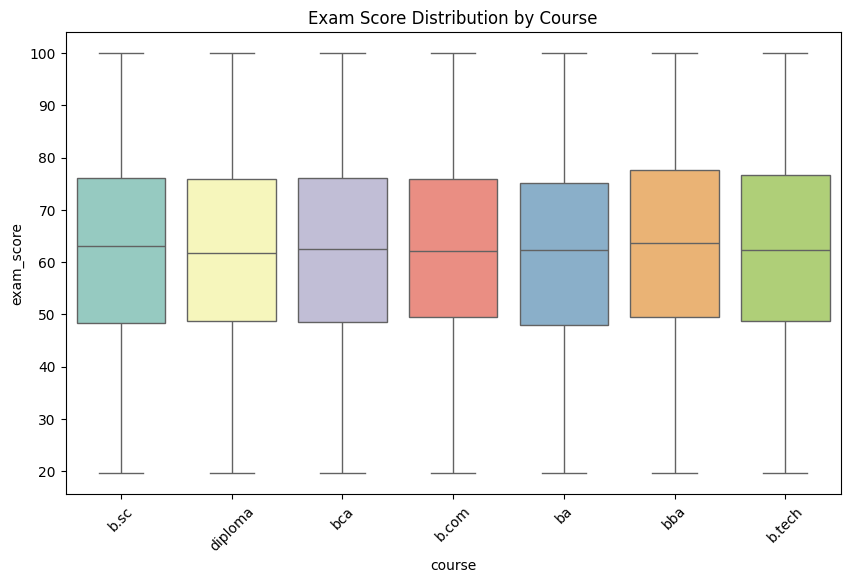

In [13]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='course', y='exam_score', hue='course', palette='Set3')
plt.title("Exam Score Distribution by Course")
plt.xticks(rotation=45)
plt.show()


> Exam scores are almost identical across different course categories!

### Does exam_score differ meaningfully by exam_difficulty level?

In [14]:
exam_score_by_difficulty = df.groupby('exam_difficulty')['exam_score'].agg(
    ['mean', 'median', 'std', 'count']
)
exam_score_by_difficulty

,mean,median,std,count
exam_difficulty,,,,
easy,62.214401,62.5,18.708772,176540
hard,62.671693,62.8,19.136236,99478
moderate,62.606060,62.5,18.956526,353982


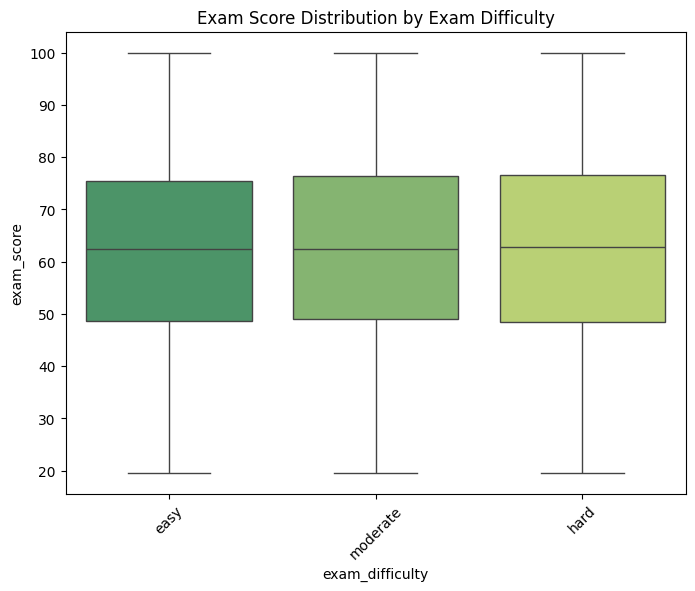

In [15]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='exam_difficulty', y='exam_score', hue='exam_difficulty', palette='summer')
plt.title("Exam Score Distribution by Exam Difficulty")
plt.xticks(rotation=45)
plt.show()

> Exam scores are almost identical across different exam difficulties!

### How strongly are numerical features (study_hours, sleep_hours, class_attendance, facility_rating) correlated with exam_score?

In [17]:
df[['study_hours', 'class_attendance', 'sleep_hours', 'exam_score']].corr()

,study_hours,class_attendance,sleep_hours,exam_score
study_hours,1.000000,0.087617,0.042491,0.762267
class_attendance,0.087617,1.000000,0.029263,0.360954
sleep_hours,0.042491,0.029263,1.000000,0.167410
exam_score,0.762267,0.360954,0.167410,1.000000


> exam_score vs study_hours → 0.762 (strong positive correlation)! As study hours increase, exam scores tend to increase a lot!  
> exam_score vs class_attendance → 0.360 (moderate positive correlation)! Higher attendance is associated with higher exam scores, but not as strongly as study hours!  
> exam_score vs sleep_hours → 0.167 (weak positive correlation)! Sleep hours have only a small linear association with exam score! 

### Does sleep_quality show diminishing or negative returns on exam_score?

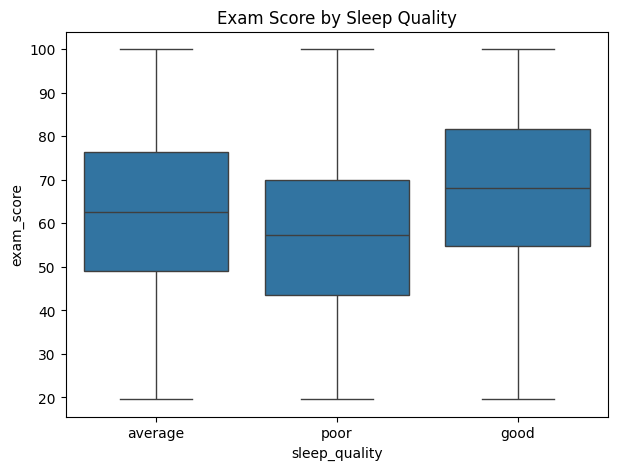

<Axes: xlabel='sleep_quality', ylabel='exam_score'>

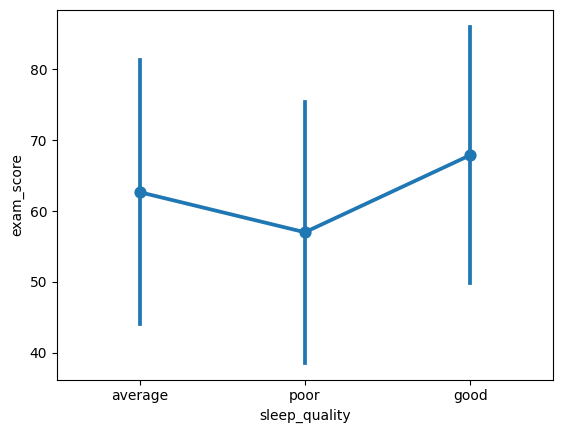

In [20]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='sleep_quality', y='exam_score')
plt.title("Exam Score by Sleep Quality")
plt.show()

sns.pointplot(data=df, x='sleep_quality', y='exam_score', errorbar='sd')

> Sleep_quality shows a small but consistent positive relationship with exam_score.  
The mean score increases from poor to average to good sleep quality. The increments do not shrink, so there is no evidence of diminishing returns or negative returns, just a mild upward trend!

### How does exam_score differ across gender categories?

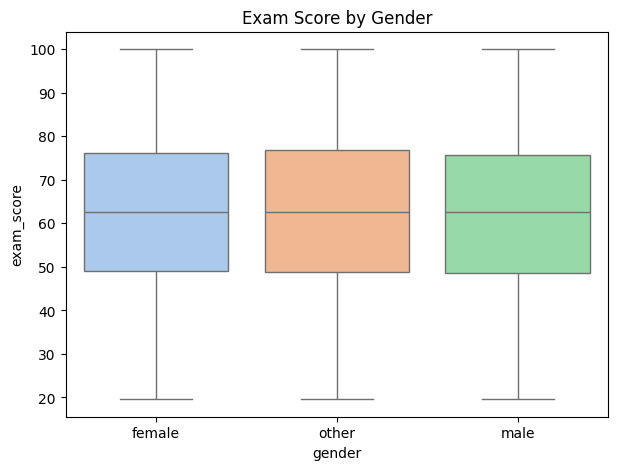

In [ ]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='gender', y='exam_score', hue='gender', palette='pastel')
plt.title("Exam Score by Gender")
plt.show()

> The exam_scores across different genders are identical!

### Are certain study_method categories consistently associated with higher or lower scores?

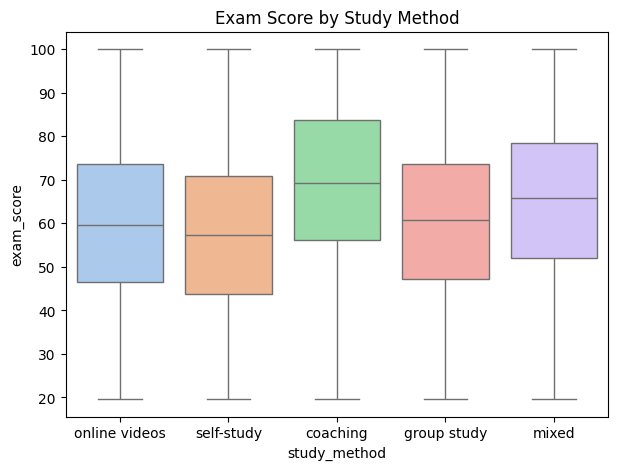

In [22]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='study_method', y='exam_score', hue='study_method', palette='pastel')
plt.title("Exam Score by Study Method")
plt.show()

> Coaching shows a consistently higher exam_score distribution, with both the median and IQR shifted upward relative to other study methods!  
Mixed study methods also perform above average. Online videos and group study fall in the middle, while self-study shows the lowest overall distribution.

### Does having internet_access significantly change score distributions?

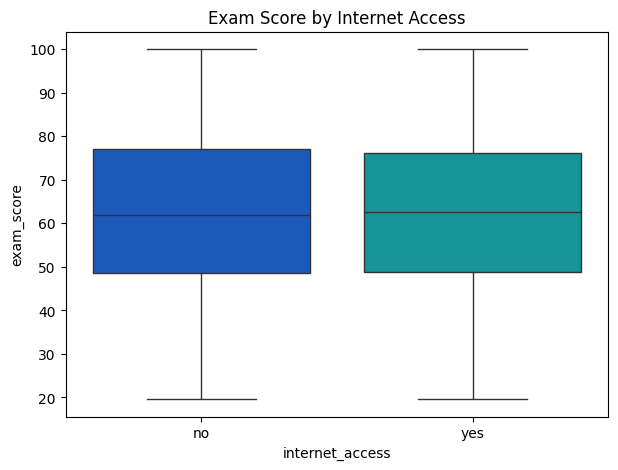

In [25]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x='internet_access', y='exam_score', hue='internet_access', palette='winter')
plt.title("Exam Score by Internet Access")
plt.show()

> exam_scores are identical between having and not having access to the internet!

### Are some course categories underrepresented or dominating the dataset?

In [26]:
df['course'].value_counts()

course
b.tech     131236
b.sc       111554
b.com      110932
bca         88721
bba         75644
ba          61989
diploma     49924
Name: count, dtype: int64

> The course distribution is imbalanced. The b.tech  category dominates the dataset with over 130k samples, followed by b.sc  and b.com  with more than 110k each!  
Mid-sized categories include bca and bba. The ba and diploma categories are relatively underrepresented, with around 62k and 50k samples respectively!

In [16]:
df.head()

,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0
